In [59]:
import pandas as pd
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt


In [60]:
# Load the dataset
df = pd.read_csv('/Users/himanshu/Documents/Smart Farming/Crop_recommendationV2.csv')

# Check the top rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Overview of data
print(df.info())

print(df.columns)



    N   P   K  temperature   humidity        ph    rainfall label  \
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice   
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice   
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice   
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice   
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice   

   soil_moisture  soil_type  ...  organic_matter  irrigation_frequency  \
0      29.446064          2  ...        3.121395                     4   
1      12.851183          3  ...        2.142021                     4   
2      29.363913          2  ...        1.474974                     1   
3      26.207732          3  ...        8.393907                     1   
4      28.236236          2  ...        5.202285                     3   

   crop_density  pest_pressure  fertilizer_usage  growth_stage  \
0     11.743910      57.607308        188.194958             1   
1     16

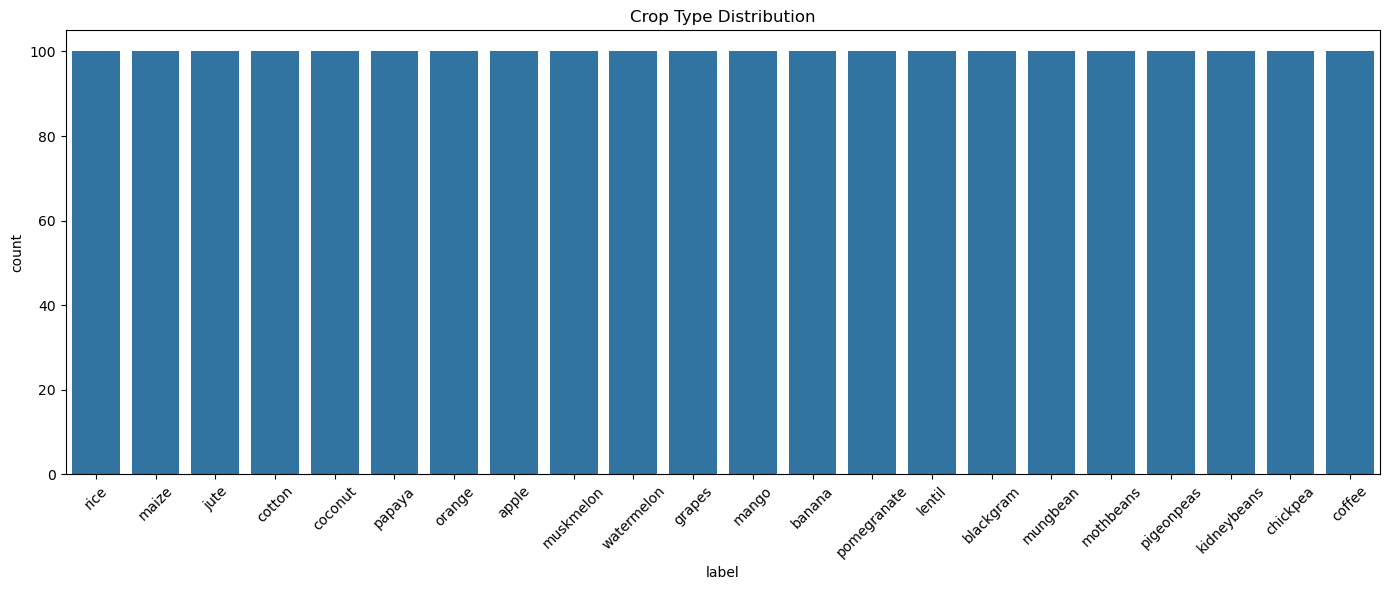

In [61]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Crop Type Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

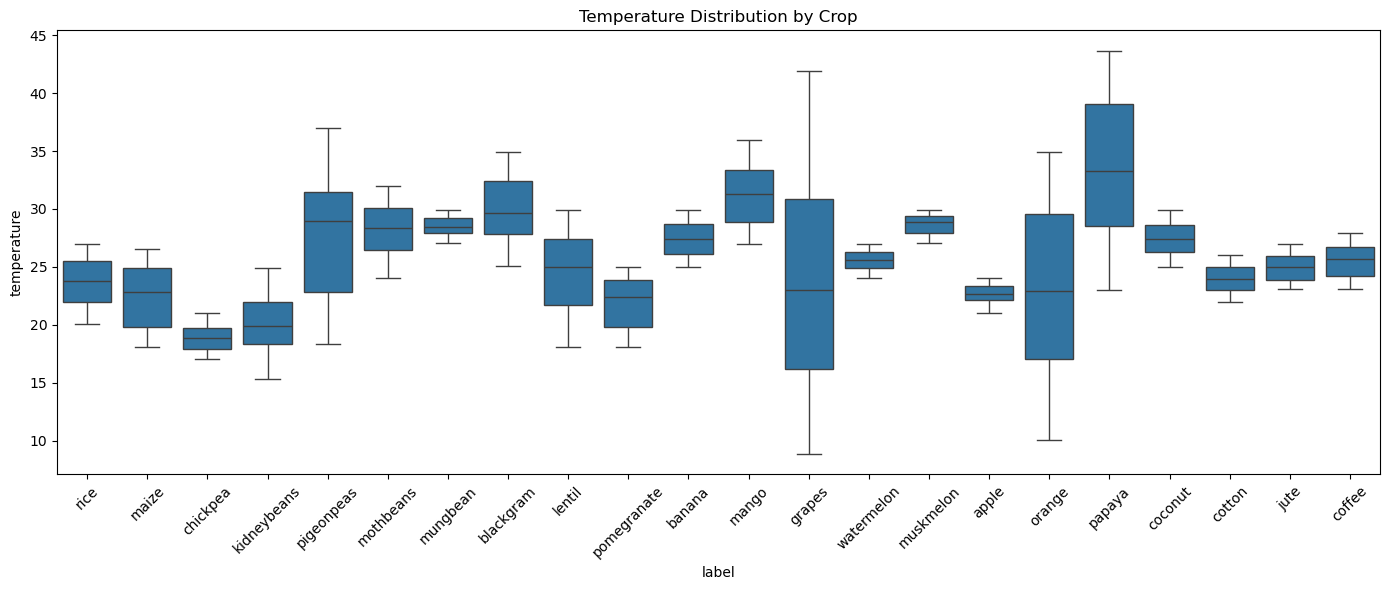

In [62]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='label', y='temperature')
plt.title('Temperature Distribution by Crop')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


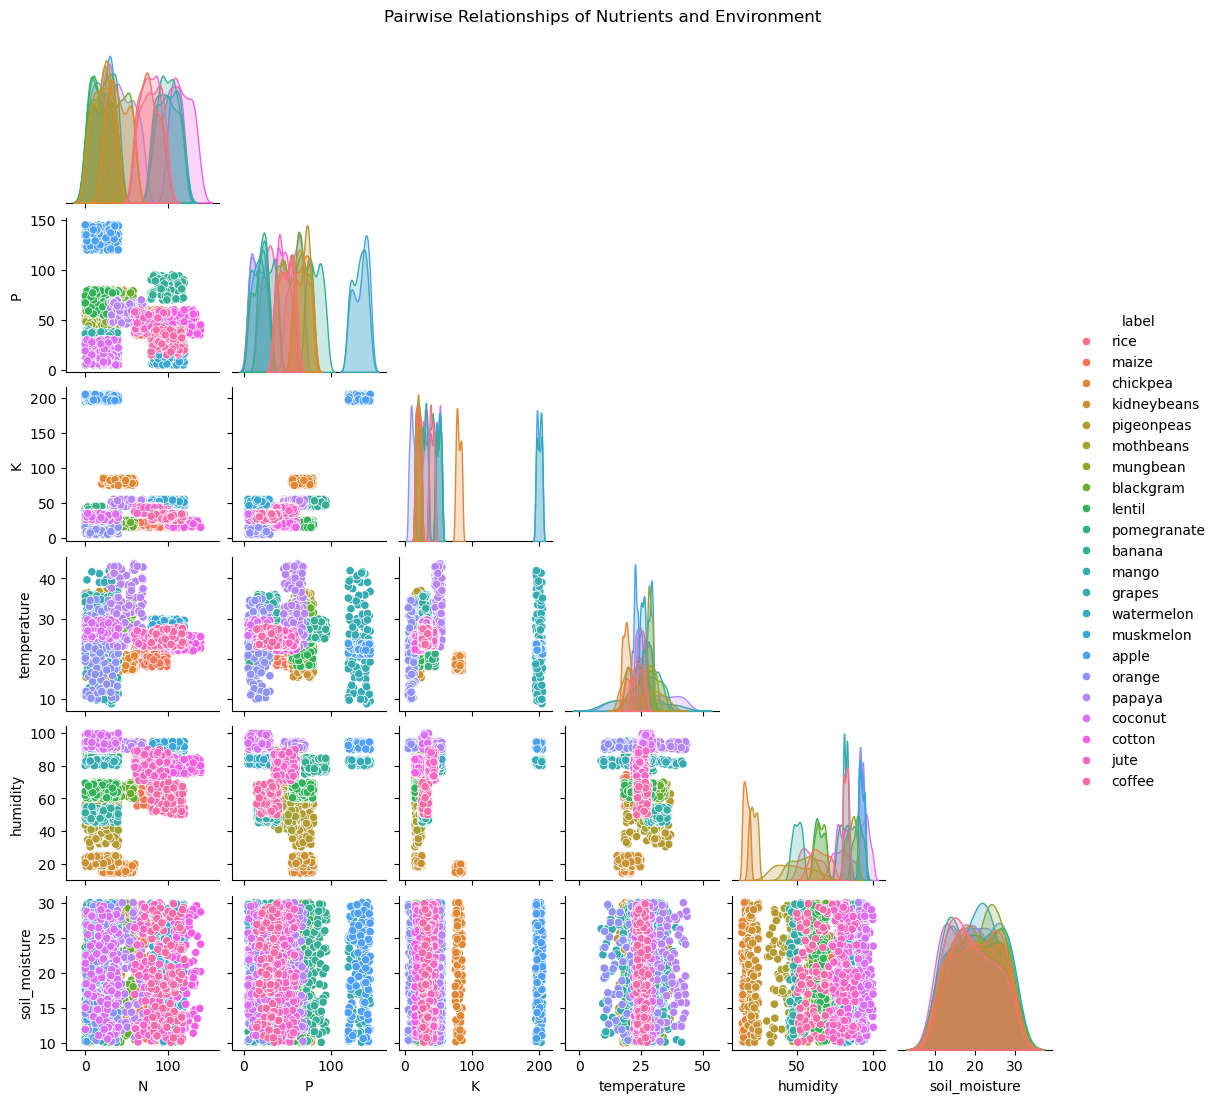

In [63]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'soil_moisture']
sns.pairplot(df[features + ['label']], hue='label', corner=True, height=1.8)
plt.suptitle("Pairwise Relationships of Nutrients and Environment", y=1.02)
plt.show()


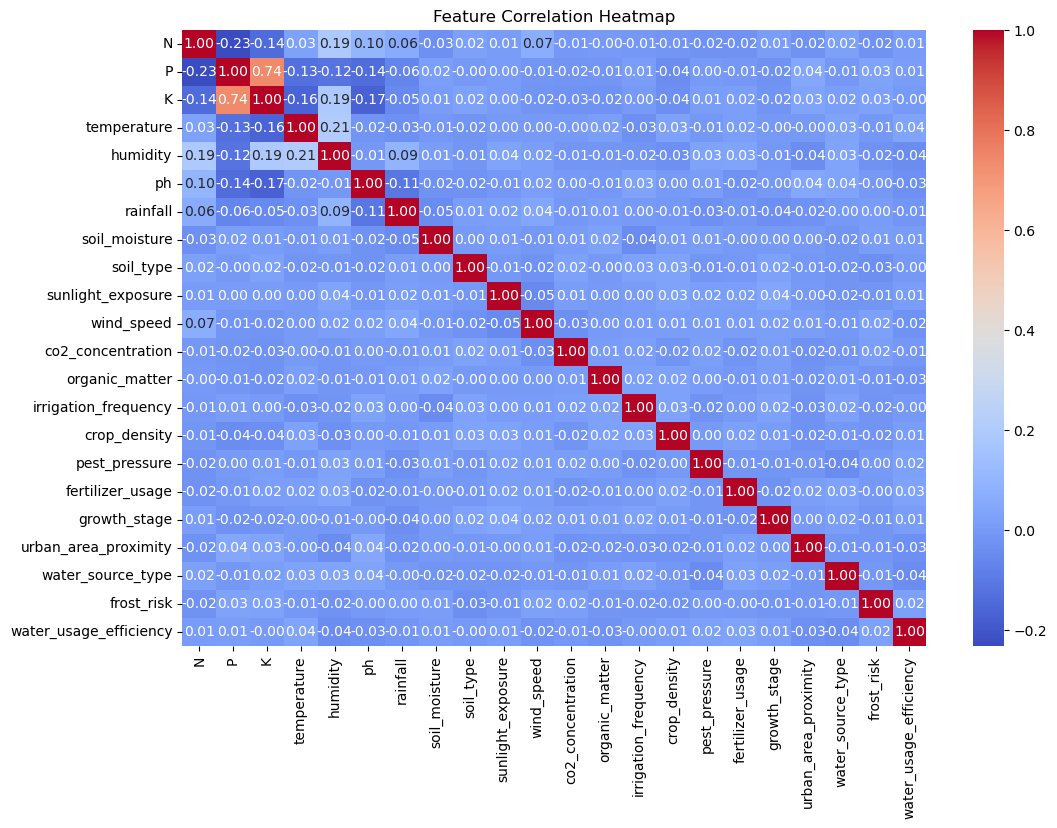

In [64]:
plt.figure(figsize=(12, 8))

# Drop non-numeric columns like 'Label' and 'Temp_cat' (or any others)
numeric_df = df.select_dtypes(include='number')

# Now compute and plot the correlation matrix
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


In [65]:
# Encode crop labels temporarily for grouping
df['label_encoded'] = df['label'].astype('category').cat.codes

# WICL: KNN Imputer on grouped data (Crop-aware)
def wicl_imputation(df, n_neighbors=3):
    imputed = pd.DataFrame()
    for label in df['label_encoded'].unique():
        subset = df[df['label_encoded'] == label]
        imputer = KNNImputer(n_neighbors=n_neighbors)
        imputed_subset = pd.DataFrame(imputer.fit_transform(subset.drop(columns='label')), columns=subset.drop(columns='label').columns)
        imputed_subset['label'] = subset['label'].values
        imputed = pd.concat([imputed, imputed_subset])
    return imputed

df_imputed = wicl_imputation(df)

In [66]:
from sklearn.preprocessing import StandardScaler

def localized_scaling(df):
    scaled_df = pd.DataFrame()
    for label in df['label'].unique():
        subset = df[df['label'] == label]
        features = subset.drop(columns=['label'])
        scaler = StandardScaler()
        scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
        scaled['label'] = label
        scaled_df = pd.concat([scaled_df, scaled])
    return scaled_df.reset_index(drop=True)

df_scaled = localized_scaling(df_imputed)


In [67]:
def afd_binning(series, bins=3, labels=None):
    if labels is None:
        labels = ['low', 'medium', 'high']
    return pd.cut(series, bins=bins, labels=labels)

# Example: Discretize Temperature
df_scaled['Temp_cat'] = afd_binning(df_scaled['temperature'])


In [68]:
# Assume ideal values (can be optimized)
ideal = {
    'temperature': 25,
    'humidity': 50,
    'soil_moisture': 30
}
weights = {
    'temperature': 0.4,
    'humidity': 0.3,
    'soil_moisture': 0.3
}

def compute_esf(row):
    esf = 0
    for feature in ideal:
        esf += abs(row[feature] - ideal[feature]) / ideal[feature] * weights[feature]
    return esf

df_scaled['ESF'] = df_scaled.apply(compute_esf, axis=1)


In [69]:
# Show top 10 rows
print(df_scaled.head(10))


          N         P         K  temperature  humidity        ph  rainfall  \
0  0.852572 -0.709442  1.067750    -1.390135 -0.191372  0.101347 -0.974374   
1  0.430924  1.324799  0.385481    -0.949424 -1.383984  0.800986 -0.279179   
2 -1.677314  0.943379  1.408884    -0.338863  0.033970  1.849718  0.814279   
3 -0.496701 -1.599422  0.044347     1.386264 -1.498265  0.725551  0.195866   
4 -0.159383 -0.709442  0.726616    -1.761009 -0.473296  1.572883  0.777734   
5 -0.918349 -1.345142  0.726616    -0.312348  0.777523  0.847214  0.435930   
6 -0.918349  0.943379 -0.637921    -0.485131  0.259760 -0.947474  1.030006   
7  1.189890  0.689099  0.044347    -1.687994  0.440216 -0.924173  0.169786   
8  0.768242  0.816239 -0.637921     0.408962  0.894509  0.339778 -0.168080   
9 -1.002678  1.324799 -0.637921    -0.230251  0.538809 -0.116649 -0.438803   

   soil_moisture  soil_type  sunlight_exposure  ...  fertilizer_usage  \
0       1.824456   0.071899          -0.104118  ...          1.43847

In [70]:
# Show only selected columns
print(df_scaled[['temperature', 'humidity', 'soil_moisture', 'ESF', 'label']].head(10))


   temperature  humidity  soil_moisture       ESF label
0    -1.390135 -0.191372       1.824456  1.005146  rice
1    -0.949424 -1.383984      -1.123533  1.034730  rice
2    -0.338863  0.033970       1.809862  0.987119  rice
3     1.386264 -1.498265       1.249184  0.974318  rice
4    -1.761009 -0.473296       1.609537  1.014921  rice
5    -0.312348  0.777523       0.788265  0.992450  rice
6    -0.485131  0.259760      -0.682528  1.013029  rice
7    -1.687994  0.440216       0.294862  1.021418  rice
8     0.408962  0.894509       1.326091  0.974829  rice
9    -0.230251  0.538809       0.922517  0.991226  rice


In [71]:
print(df_scaled.columns)


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall',
       'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed',
       'co2_concentration', 'organic_matter', 'irrigation_frequency',
       'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage',
       'urban_area_proximity', 'water_source_type', 'frost_risk',
       'water_usage_efficiency', 'label_encoded', 'label', 'Temp_cat', 'ESF'],
      dtype='object')


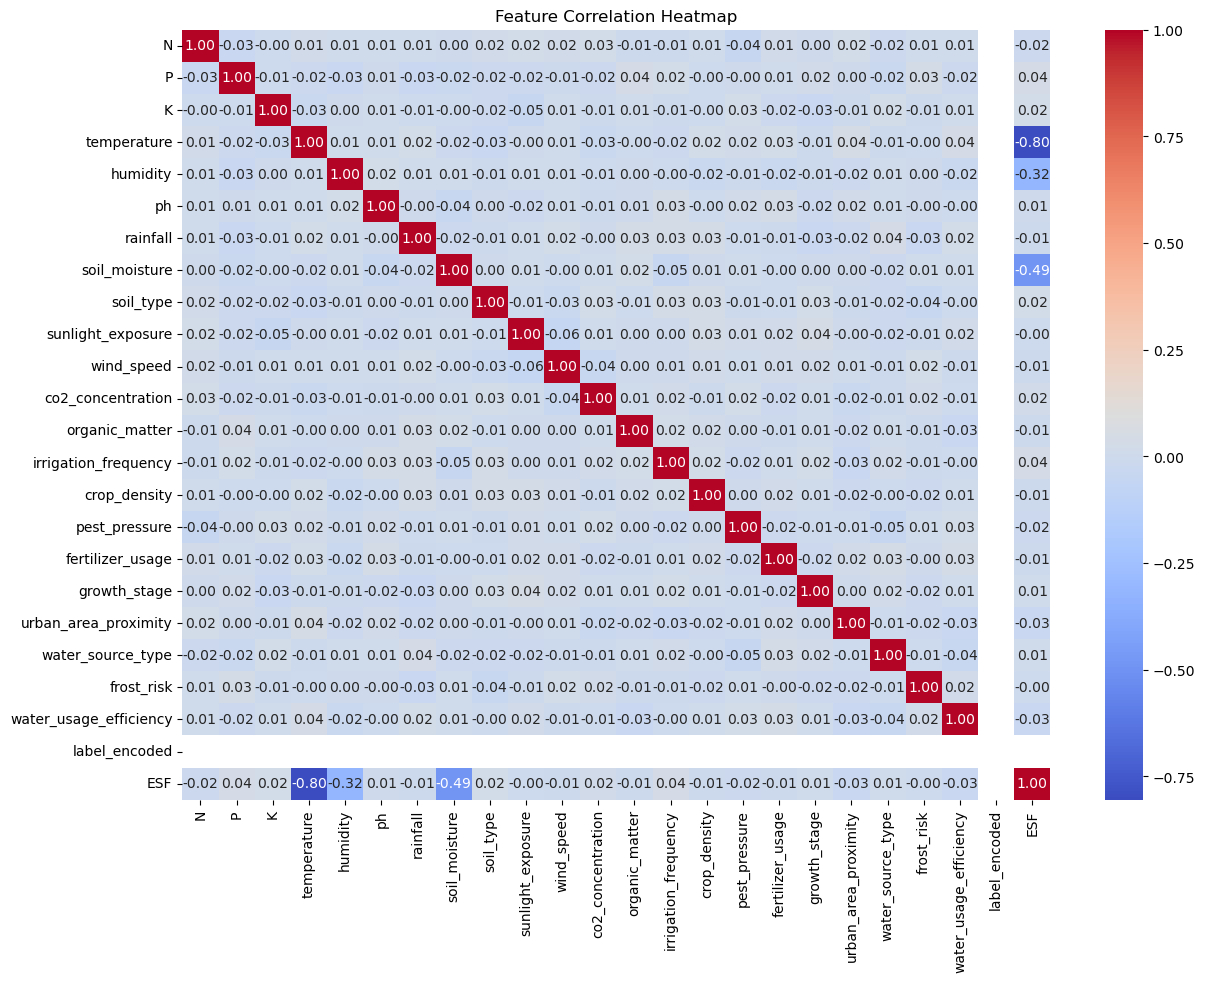

In [72]:
# Drop both Label and any non-numeric categorical columns like 'Temp_cat'
numeric_df = df_scaled.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


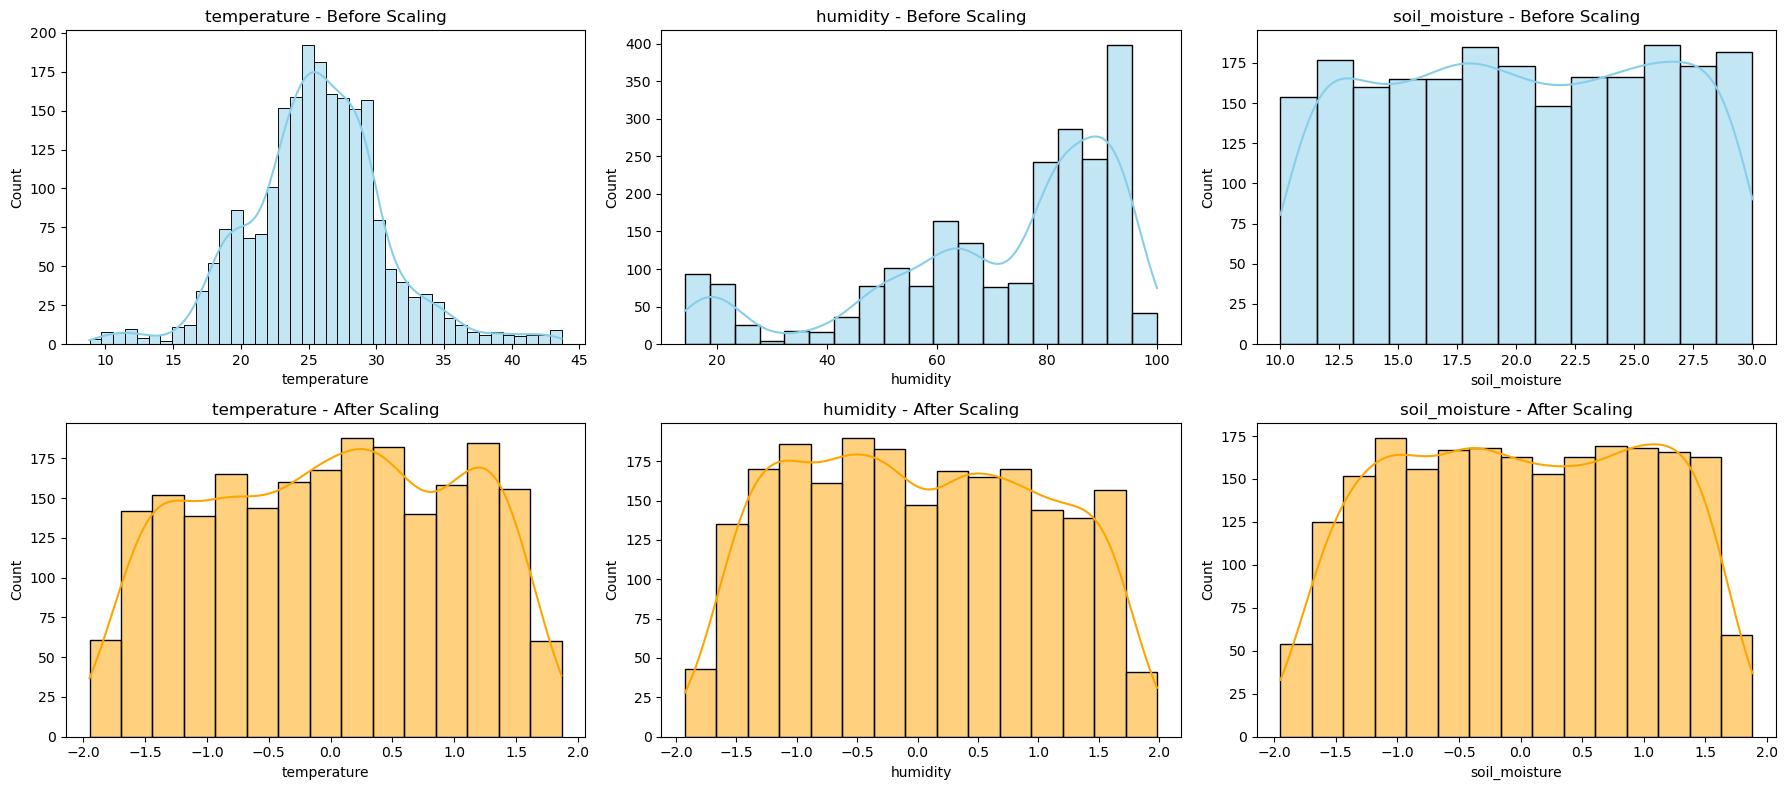

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
features = ['temperature', 'humidity', 'soil_moisture']

for i, col in enumerate(features):
    # Before scaling
    sns.histplot(df_imputed[col], ax=axes[0, i], kde=True, color='skyblue')
    axes[0, i].set_title(f"{col} - Before Scaling")
    
    # After scaling
    sns.histplot(df_scaled[col], ax=axes[1, i], kde=True, color='orange')
    axes[1, i].set_title(f"{col} - After Scaling")

plt.tight_layout()
plt.show()


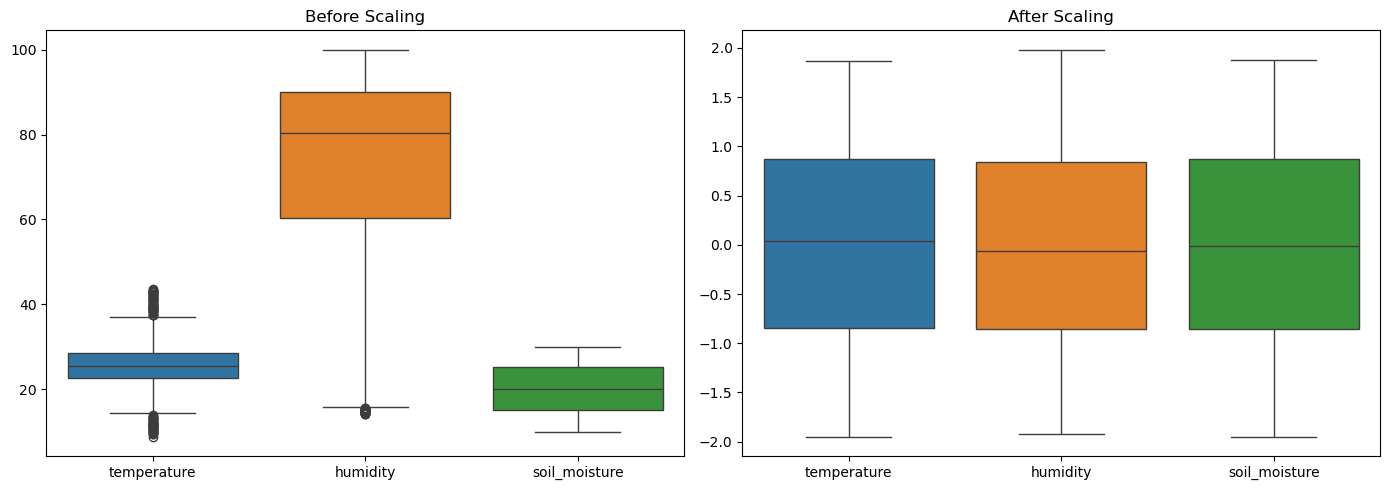

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_imputed[features], ax=axes[0])
axes[0].set_title("Before Scaling")

sns.boxplot(data=df_scaled[features], ax=axes[1])
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()


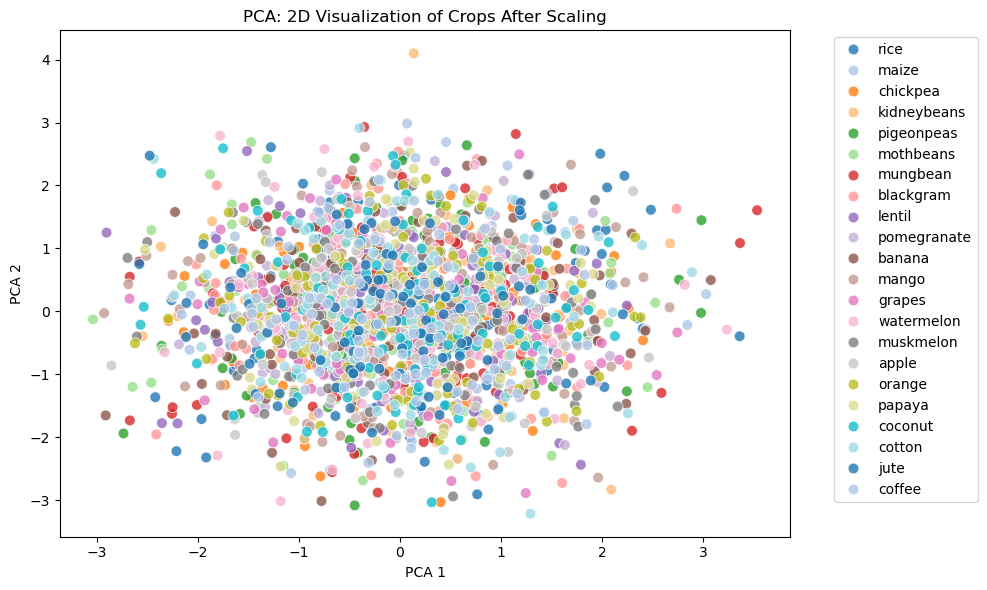

In [75]:
from sklearn.decomposition import PCA

# Drop any non-numeric columns (like 'Label', 'Temp_cat', etc.)
X = df_scaled.select_dtypes(include=['float64', 'int64'])
y = df_scaled['label']

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=y, palette='tab20', s=60, alpha=0.8)
plt.title("PCA: 2D Visualization of Crops After Scaling")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [76]:
pip install pytorch-tabnet


Note: you may need to restart the kernel to use updated packages.


In [77]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [78]:
from sklearn.preprocessing import LabelEncoder

# Encode all object or category columns (like 'low', 'medium', etc.)
for col in df_scaled.columns:
    if df_scaled[col].dtype == 'object' or str(df_scaled[col].dtype) == 'category':
        le = LabelEncoder()
        df_scaled[col] = le.fit_transform(df_scaled[col].astype(str))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5145
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 24
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.103621
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.169004
[LightGBM] [Info] Start training from score -3.182610
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.018722
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -2.984433
[LightGBM] [Info] Start training from score -3.103621
[LightGBM] [Info] Start training from score -3.078620
[LightGBM]

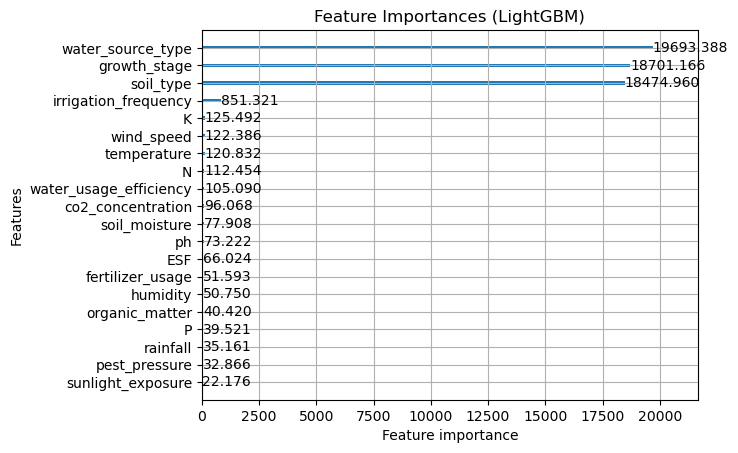

In [79]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Prepare features and labels
X = df_scaled.drop(columns=['label'])  # Drop label for feature selection
y = LabelEncoder().fit_transform(df_scaled['label'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a LightGBM model
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)

# Plot feature importance
import matplotlib.pyplot as plt
lgb.plot_importance(lgb_model, max_num_features=20, importance_type='gain')
plt.title("Feature Importances (LightGBM)")
plt.show()


In [80]:
from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np

# Convert to numpy
X_train_np = X_train.values
y_train_np = y_train
X_test_np = X_test.values
y_test_np = y_test

# TabNet model
tabnet = TabNetClassifier()
tabnet.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=200,
    patience=20,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# Accuracy
from sklearn.metrics import accuracy_score
y_pred = tabnet.predict(X_test_np)
acc = accuracy_score(y_test_np, y_pred)
print("TabNet Accuracy:", round(acc * 100, 2), "%")


/opt/anaconda3/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.68355 | val_accuracy: 0.05    |  0:00:00s
epoch 1  | loss: 3.2328  | val_accuracy: 0.04773 |  0:00:00s
epoch 2  | loss: 3.13149 | val_accuracy: 0.025   |  0:00:00s
epoch 3  | loss: 3.10155 | val_accuracy: 0.04091 |  0:00:00s
epoch 4  | loss: 3.08355 | val_accuracy: 0.04318 |  0:00:00s
epoch 5  | loss: 3.08653 | val_accuracy: 0.04091 |  0:00:00s
epoch 6  | loss: 3.08304 | val_accuracy: 0.02727 |  0:00:00s
epoch 7  | loss: 3.07603 | val_accuracy: 0.04091 |  0:00:00s
epoch 8  | loss: 3.08272 | val_accuracy: 0.03409 |  0:00:00s
epoch 9  | loss: 3.0759  | val_accuracy: 0.03182 |  0:00:00s
epoch 10 | loss: 3.07111 | val_accuracy: 0.03409 |  0:00:00s
epoch 11 | loss: 3.07075 | val_accuracy: 0.03182 |  0:00:00s
epoch 12 | loss: 3.06064 | val_accuracy: 0.05682 |  0:00:00s
epoch 13 | loss: 3.05607 | val_accuracy: 0.05455 |  0:00:00s
epoch 14 | loss: 3.05489 | val_accuracy: 0.04091 |  0:00:00s
epoch 15 | loss: 3.05059 | val_accuracy: 0.04773 |  0:00:00s
epoch 16 | loss: 3.04393

/opt/anaconda3/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Precision, Recall, F1 (macro average for multi-class)
precision = precision_score(y_test_np, y_pred, average='macro') * 100
recall = recall_score(y_test_np, y_pred, average='macro') * 100
f1 = f1_score(y_test_np, y_pred, average='macro') * 100

print(f"TabNet Precision: {precision:.2f}%")
print(f"TabNet Recall: {recall:.2f}%")
print(f"TabNet F1 Score: {f1:.2f}%")

TabNet Precision: 7.15%
TabNet Recall: 5.95%
TabNet F1 Score: 3.71%


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [82]:
!pip install transformers4tabular --quiet
!pip install category_encoders scikit-learn==1.2.2


ERROR: Could not find a version that satisfies the requirement transformers4tabular (from versions: none)
ERROR: No matching distribution found for transformers4tabular


PermutationExplainer explainer: 101it [00:46,  1.72it/s]                        
/var/folders/99/hpp5955x56z14tkg_b6sc0k40000gn/T/ipykernel_26149/524072495.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test_np[:100], feature_names=X_test.columns)


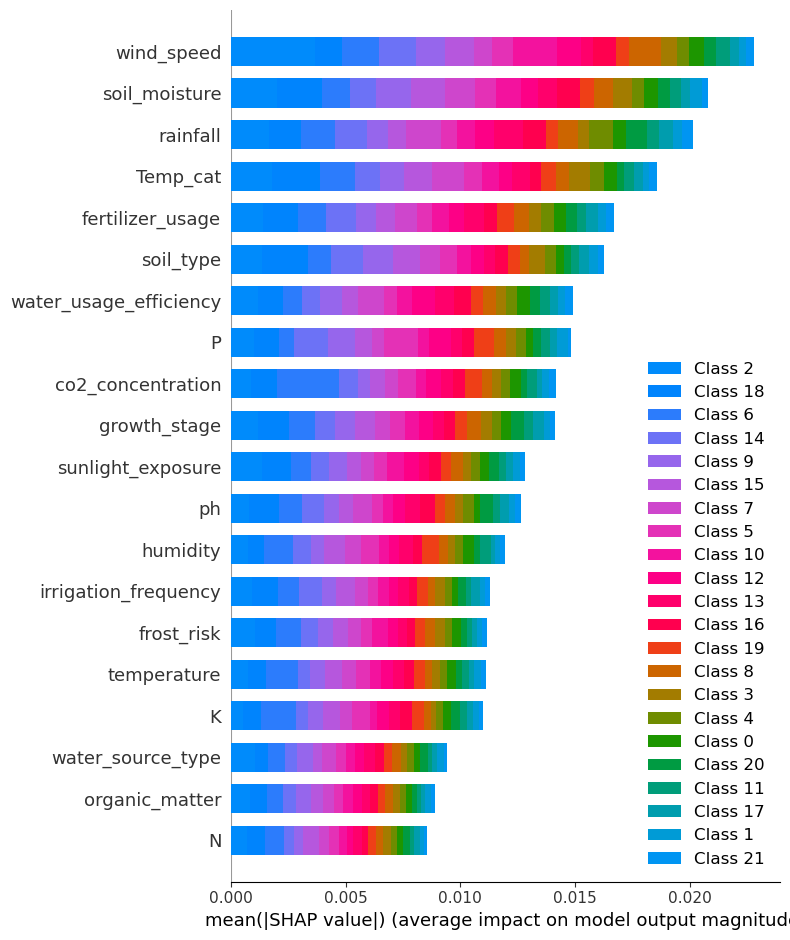

In [83]:
import shap

# SHAP needs a tree model or a wrapper for neural nets
explainer = shap.Explainer(tabnet.predict_proba, X_test_np)
shap_values = explainer(X_test_np[:100])  # Only first 100 samples for speed

# Summary plot
shap.summary_plot(shap_values, features=X_test_np[:100], feature_names=X_test.columns)


    N   P   K  temperature   humidity        ph    rainfall label  \
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice   
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice   
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice   
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice   
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice   

   soil_moisture  soil_type  ...  organic_matter  irrigation_frequency  \
0      29.446064          2  ...        3.121395                     4   
1      12.851183          3  ...        2.142021                     4   
2      29.363913          2  ...        1.474974                     1   
3      26.207732          3  ...        8.393907                     1   
4      28.236236          2  ...        5.202285                     3   

   crop_density  pest_pressure  fertilizer_usage  growth_stage  \
0     11.743910      57.607308        188.194958             1   
1     16

/var/folders/99/hpp5955x56z14tkg_b6sc0k40000gn/T/ipykernel_26149/2698801119.py:43: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X.columns)
/opt/anaconda3/lib/python3.12/site-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/opt/anaconda3/lib/python3.12/site-packages/shap/plots/_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legac

<Figure size 640x480 with 0 Axes>

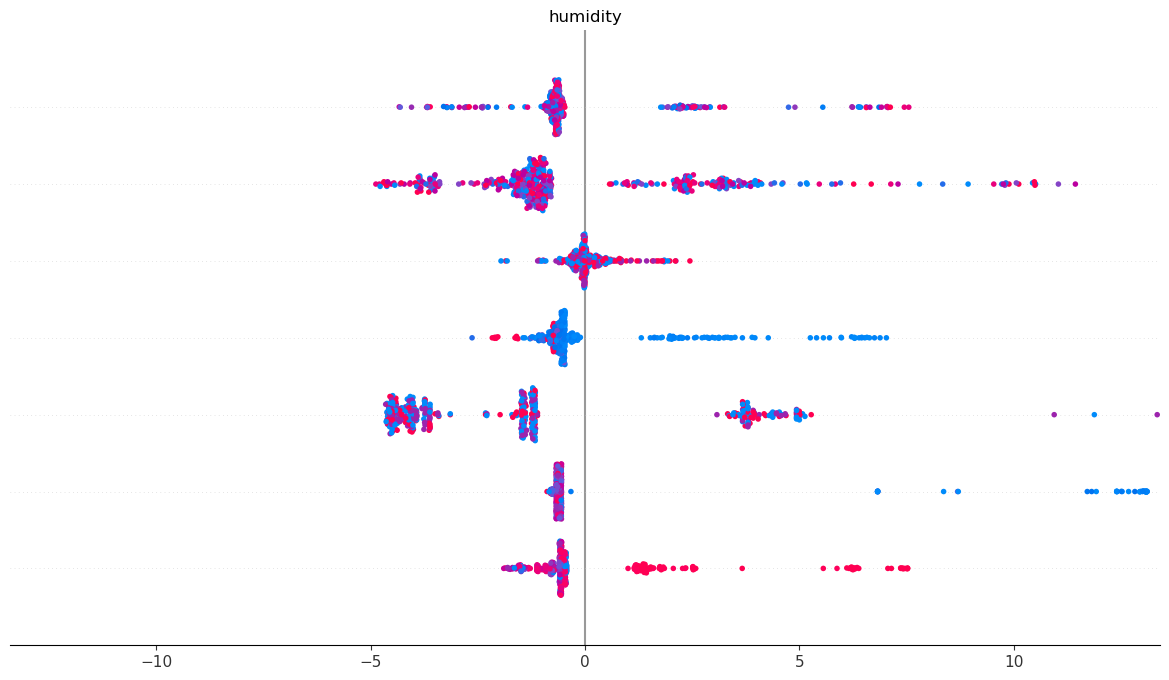

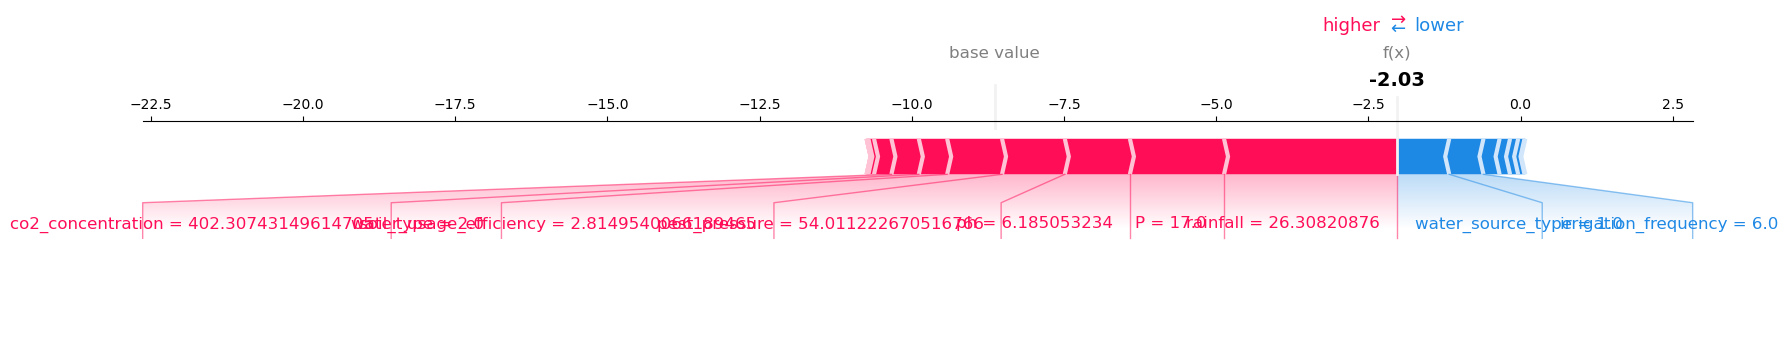

In [84]:
# 📦 Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

# 📂 Step 2: Load the data
df = pd.read_csv("Crop_recommendationV2.csv")

# 👀 Check the data
print(df.head())

# 🧹 Step 3: Preprocessing
# Encode categorical target if needed
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # 'label' = crop name

# Features and labels
X = df.drop("label", axis=1)
y = df["label"]

# 🧪 Step 4: Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🚀 Step 5: Train LightGBM model
model = lgb.LGBMClassifier()
model.fit(X_train, y_train)

# 📊 Step 6: Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 🔍 Step 7: SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Optional: Explanation for one prediction
sample_idx = 0
shap.force_plot(explainer.expected_value[0], shap_values[0][sample_idx], X_test.iloc[sample_idx], matplotlib=True)


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import shap
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [86]:
# Load the dataset
df = pd.read_csv("Crop_recommendationV2.csv")

# Preview the first few rows
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [87]:
# Encode target labels (crop names)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # Assumes 'label' is the target column

# Define features and target
X = df.drop("label", axis=1)
y = df["label"]


In [88]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [89]:
# Train a LightGBM classifier
model = lgb.LGBMClassifier()
model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4162
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 22
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.103621
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.169004
[LightGBM] [Info] Start training from score -3.182610
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.018722
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -2.984433
[LightGBM] [Info] Start training from score -3.103621
[LightGBM] [Info] Start training from score -3.078620
[LightGBM]

LGBMClassifier()

In [90]:
# Predict on the test set
y_pred = model.predict(X_test)

# Accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(
    y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9863636363636363
Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       0.95      1.00      0.97        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00     

/var/folders/99/hpp5955x56z14tkg_b6sc0k40000gn/T/ipykernel_26149/2398925482.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X.columns)
/opt/anaconda3/lib/python3.12/site-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/opt/anaconda3/lib/python3.12/site-packages/shap/plots/_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy

<Figure size 640x480 with 0 Axes>

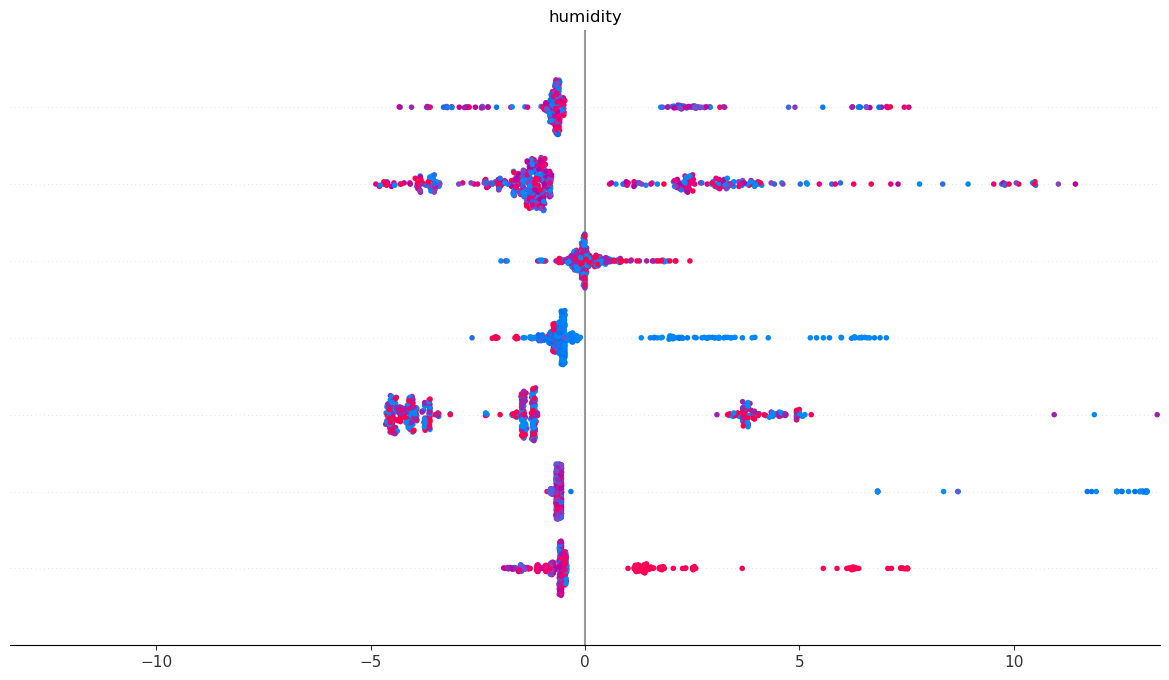

In [91]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)


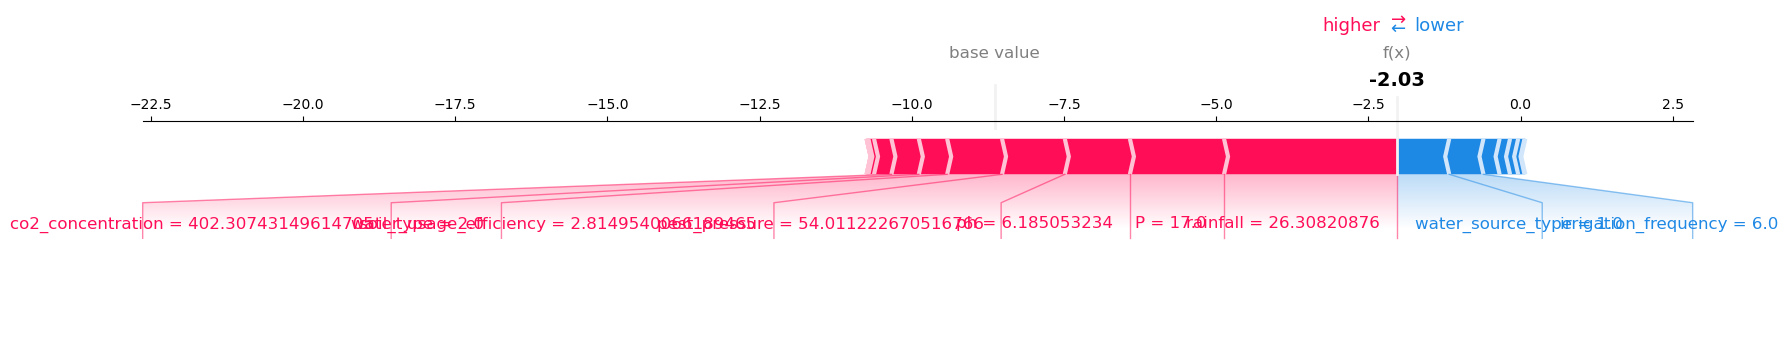

In [92]:
# Optional: SHAP force plot for a single prediction
sample_idx = 0
shap.force_plot(explainer.expected_value[0], shap_values[0][sample_idx],
                X_test.iloc[sample_idx], matplotlib=True)


In [93]:
# Assume you have:
#   y_test   — true labels for the test set
#   y_pred   — model predictions on X_test

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")


Accuracy : 0.9864
Precision: 0.9877
Recall   : 0.9864


/var/folders/99/hpp5955x56z14tkg_b6sc0k40000gn/T/ipykernel_26149/4175719223.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test[:100], feature_names=X_test.columns)
/opt/anaconda3/lib/python3.12/site-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/opt/anaconda3/lib/python3.12/site-packages/shap/plots/_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warn

<Figure size 640x480 with 0 Axes>

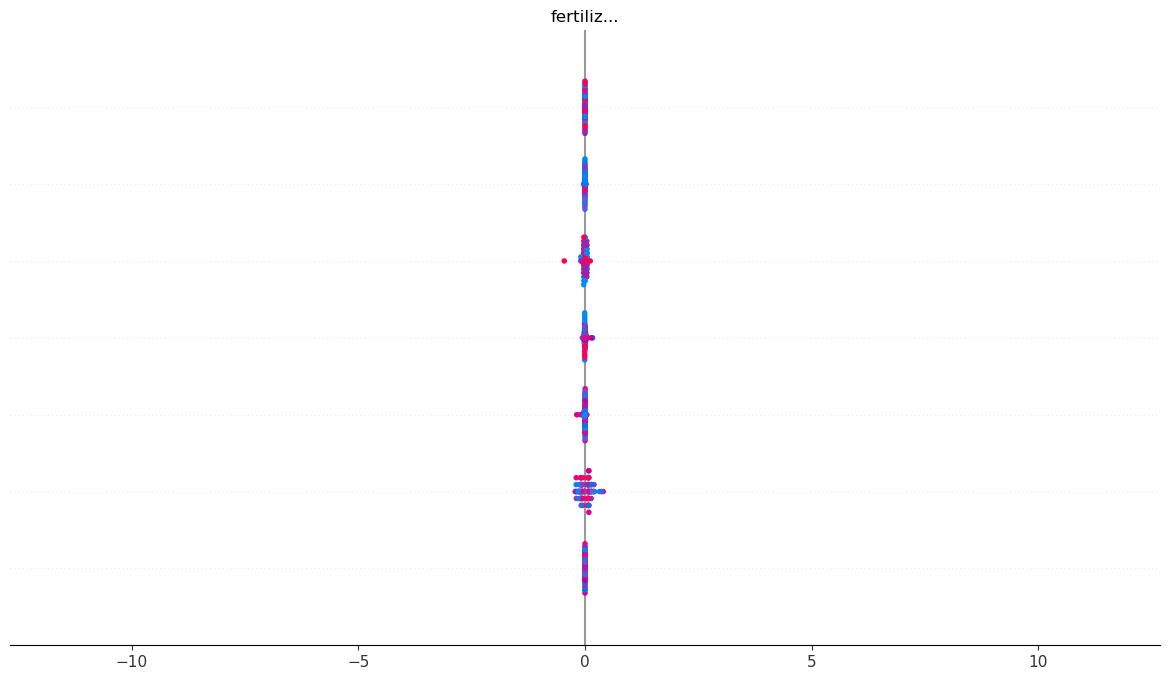

In [138]:
import shap

# Make sure your model and test data are ready
# model = your trained LightGBM model
# X_test = your test DataFrame (not a NumPy array)

# Step 1: Use SHAP's TreeExplainer for LightGBM
explainer = shap.TreeExplainer(model)

# Step 2: Compute SHAP values
shap_values = explainer.shap_values(X_test[:100])  # Use a subset for speed

# Step 3: Plot SHAP summary
shap.summary_plot(shap_values, features=X_test[:100], feature_names=X_test.columns)


# CatBoost

In [95]:
!pip install catBoost

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool
import shap


In [97]:
# Encode crop labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# Separate features and target
X = df.drop("label", axis=1)
y = df["label"]


In [98]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [99]:
# Ensure y_pred is an integer array (not object or nested)
y_pred = model.predict(X_test)
y_pred = y_pred.astype(int).flatten()

# Evaluate
target_names = [str(cls) for cls in label_encoder.classes_]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))



Accuracy: 0.9863636363636363
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.85      1.00      0.92        11
          11       1.00      0.95      0.98        21
          12       0.95      1.00      0.97        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00     

# New Model from Scratch

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import precision_score, accuracy_score, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [102]:
df_raw = pd.read_csv('/Users/himanshu/Desktop/Crop_recommendationV2.csv')
df_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/himanshu/Desktop/Crop_recommendationV2.csv'

In [ ]:
print(df_raw.columns)

In [ ]:
print(df_raw.isnull().values.any())

In [ ]:
# move target column 'label' to be the last column

df = df_raw.copy(deep=True)
df = df.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,7]]

In [ ]:
# train-test split
# the test set will contain one-tenth of the observations for each label

crops = df['label'].unique()
idx_test = []

random.seed(27)
for i in range(len(crops)):
    crop_idx = df.index[df['label']==crops[i]].tolist()
    crop_idx_test = random.sample(crop_idx, len(crop_idx)//10)
    idx_test += crop_idx_test
    
df_test = df.iloc[idx_test]
df = df.drop(idx_test)

# EDA

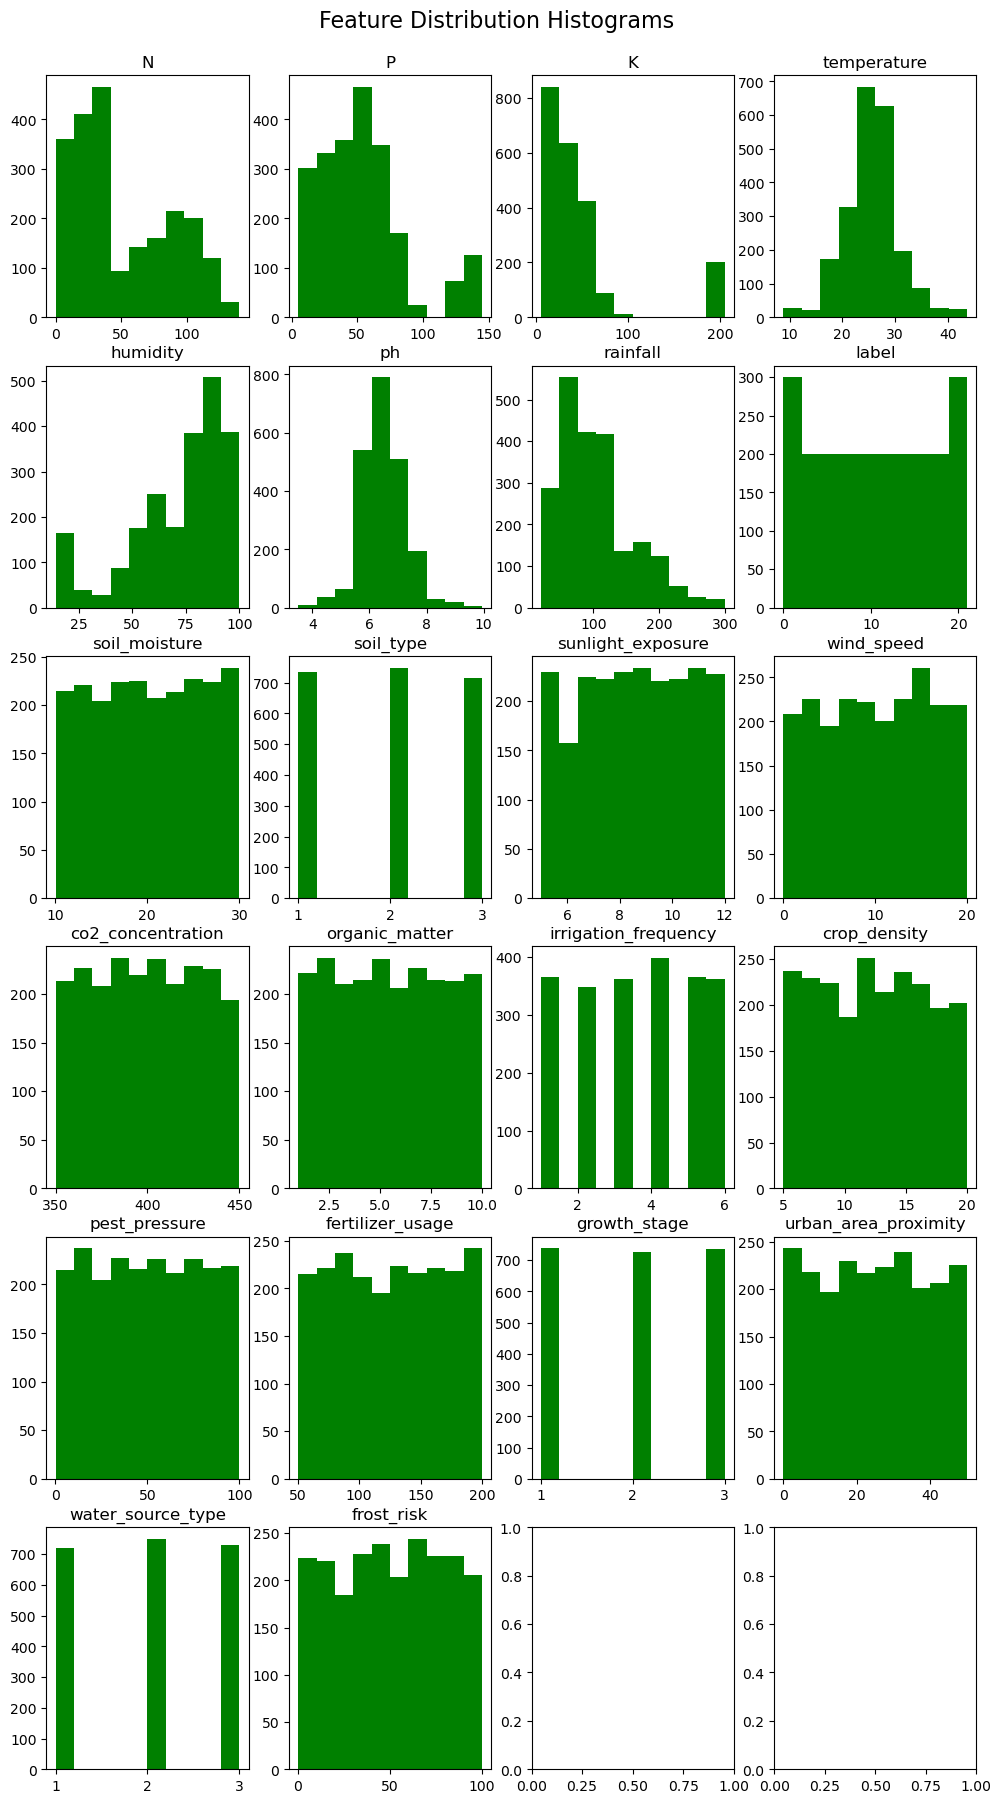

In [113]:
# plot histograms of each feature

fig, axs = plt.subplots(6,4, figsize=(12,22), constrained_layout=False)
fig.suptitle('Feature Distribution Histograms', y=0.91, fontsize=16)

for i in range(22):
    axs[i//4, i%4].hist(df.iloc[:,i], color='green')
    axs[i//4, i%4].set_title(df.columns[i])

In [115]:
# get dummies of categorical predictors and labels

# convert cagetorical features from numerical
df.loc[:,'soil_type'].replace(1, 'sandy', inplace=True)
df.loc[:,'soil_type'].replace(2, 'loamy', inplace=True)
df.loc[:,'soil_type'].replace(3, 'clay', inplace=True)

df.loc[:,'growth_stage'].replace(1, 'seedling', inplace=True)
df.loc[:,'growth_stage'].replace(2, 'vegetative', inplace=True)
df.loc[:,'growth_stage'].replace(3, 'flowering', inplace=True)

df.loc[:,'water_source_type'].replace(1, 'river', inplace=True)
df.loc[:,'water_source_type'].replace(2, 'groundwater', inplace=True)
df.loc[:,'water_source_type'].replace(3, 'recycled', inplace=True)

# get dummies
df_dummies = pd.get_dummies(df)

# remove redundant categories
df_dummies = df_dummies.drop(['soil_type_clay', 'growth_stage_flowering', 'water_source_type_recycled'], axis=1)

/var/folders/99/hpp5955x56z14tkg_b6sc0k40000gn/T/ipykernel_26149/3738395856.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.loc[:,'soil_type'].replace(1, 'sandy', inplace=True)
/var/folders/99/hpp5955x56z14tkg_b6sc0k40000gn/T/ipykernel_26149/3738395856.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

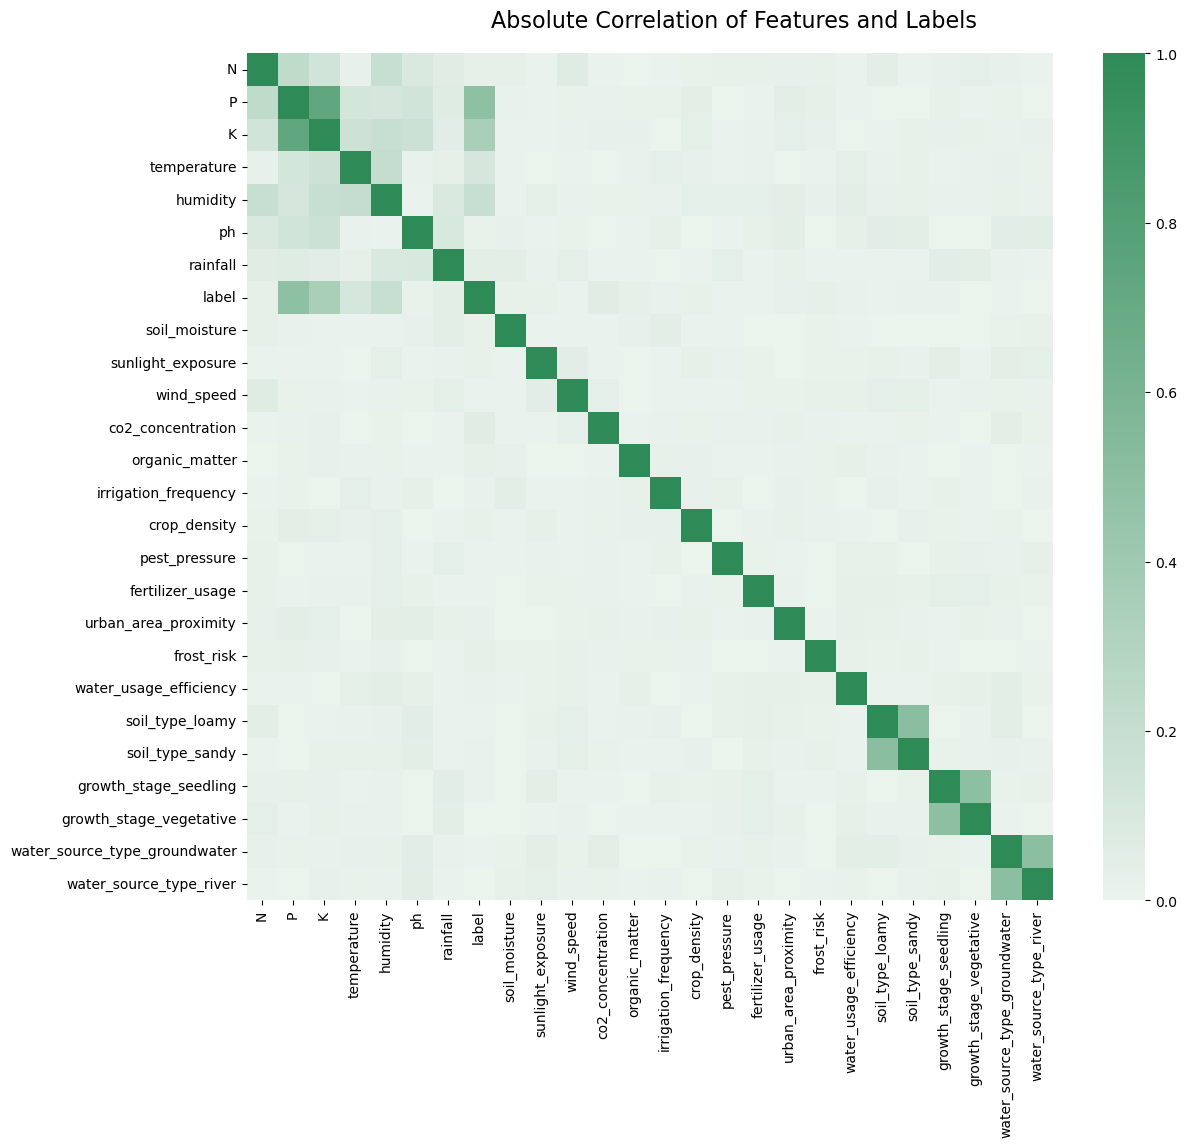

In [117]:
# plot correlation heatmap of features and labels

corr_mat = np.abs(df_dummies.corr())

fig, ax = plt.subplots(figsize=(13, 11))
fig.suptitle('Absolute Correlation of Features and Labels', y=0.92, fontsize=16)
sns.heatmap(corr_mat, ax=ax, vmin=0, vmax=1,
            cmap=sns.light_palette('seagreen', as_cmap=True))
plt.show()

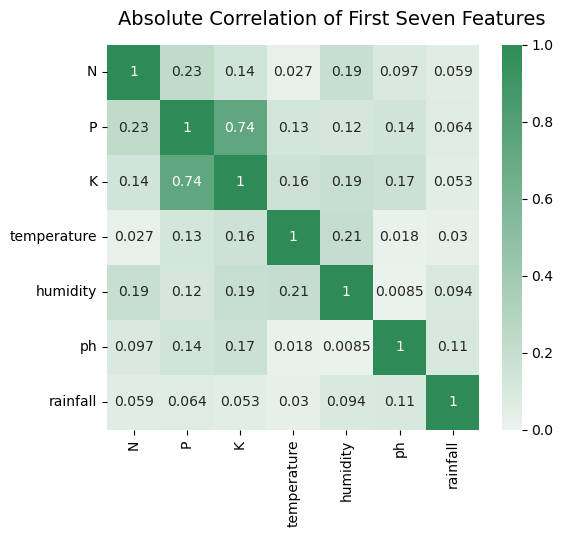

In [119]:
# plot correlation between first 7 features

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Absolute Correlation of First Seven Features', y=0.95, fontsize=14)

sns.heatmap(corr_mat.iloc[0:7,0:7], annot=True, ax=ax, vmin=0, vmax=1,
            cmap=sns.light_palette('seagreen', as_cmap=True))
plt.show()

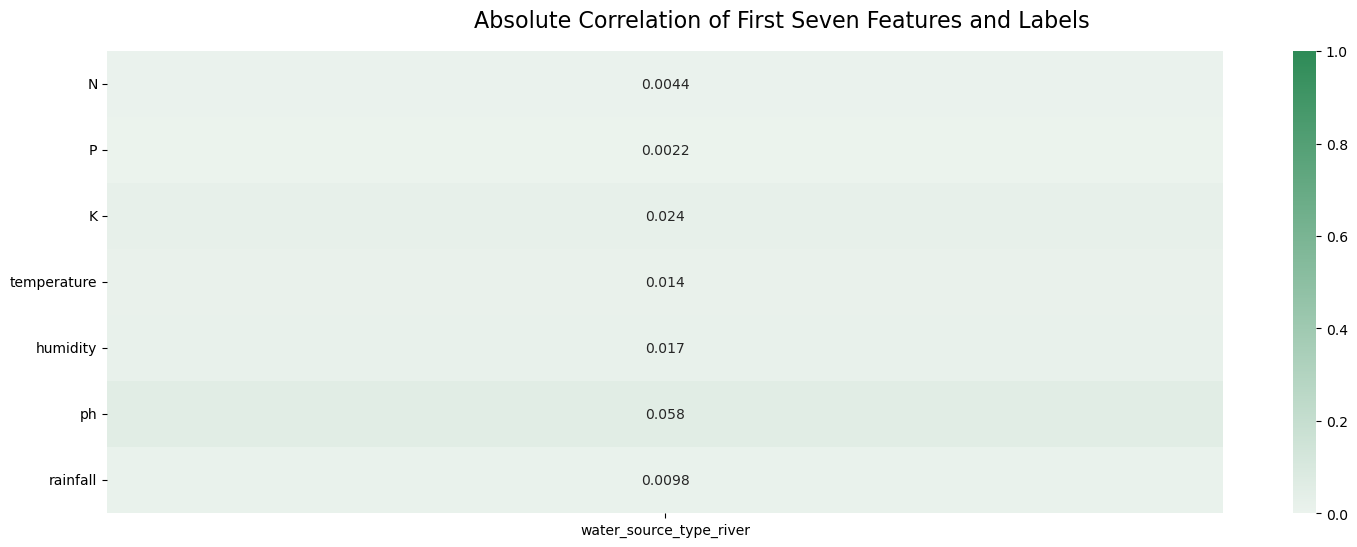

In [121]:
# plot correlation between first 7 features and labels

fig, ax = plt.subplots(figsize=(18, 6))
fig.suptitle('Absolute Correlation of First Seven Features and Labels', y=0.95, fontsize=16)

sns.heatmap(corr_mat.iloc[0:7,25:], annot=True, ax=ax, vmin=0, vmax=1,
            cmap=sns.light_palette('seagreen', as_cmap=True))
plt.show()

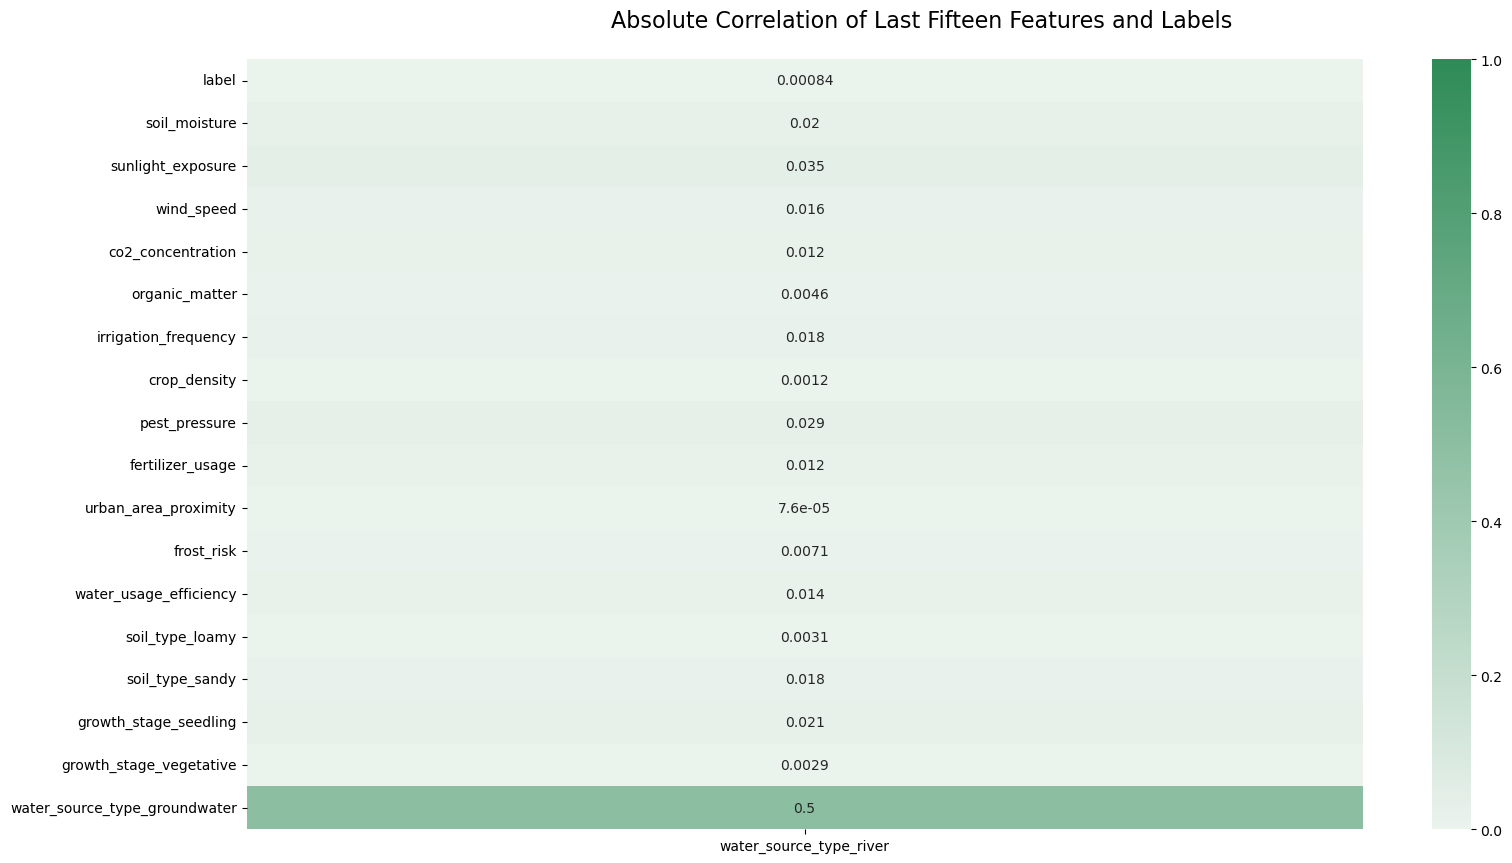

In [123]:
# plot correlation between remaining 15 features and labels

fig, ax = plt.subplots(figsize=(18, 10))
fig.suptitle('Absolute Correlation of Last Fifteen Features and Labels', y=0.93, fontsize=16)

sns.heatmap(corr_mat.iloc[7:25,25:], annot=True, ax=ax, vmin=0, vmax=1,
            cmap=sns.light_palette('seagreen', as_cmap=True))
plt.show()

In [125]:
# create simulated dataset with truly random values

df_sim = df_raw.copy(deep=True)
df_sim = df_sim.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,7]]
df_sim = df_sim.drop(idx_test)

df_sim = df_sim.drop(columns=df_sim.columns[7:22])

np.random.seed(29)
random.seed(30)

# generate random values from uniform distributions
# possible value ranges match the ranges of the true features
soil_moisture_sim = np.random.uniform(10, 30, len(df_sim))
soil_type_sim = random.choices([1,2,3], k=len(df_sim))
sunlight_exposure_sim = np.random.uniform(5, 12, len(df_sim))
wind_speed_sim = np.random.uniform(0, 20, len(df_sim))
co2_concentration_sim = np.random.uniform(350, 450, len(df_sim))
organic_matter_sim = np.random.uniform(1, 10, len(df_sim))
irrigation_frequency_sim = np.random.uniform(1, 6, len(df_sim))
crop_density_sim = np.random.uniform(5, 20, len(df_sim))
pest_pressure_sim = np.random.uniform(0, 100, len(df_sim))
fertilizer_usage_sim = np.random.uniform(50, 200, len(df_sim))
growth_stage_sim = random.choices([1,2,3], k=len(df_sim))
urban_area_proximity_sim = np.random.uniform(0, 50, len(df_sim))
water_source_type_sim = random.choices([1,2,3], k=len(df_sim))
frost_risk_sim = np.random.uniform(0, 100, len(df_sim))
water_usage_efficiency_sim = np.random.uniform(1, 5, len(df_sim))

df_sim['soil_moisture_sim'] = soil_moisture_sim
df_sim['soil_type_sim'] = soil_type_sim
df_sim['sunlight_exposure_sim'] = sunlight_exposure_sim
df_sim['wind_speed_sim'] = wind_speed_sim
df_sim['co2_concentration_sim'] = co2_concentration_sim
df_sim['organic_matter_sim'] = organic_matter_sim
df_sim['irrigation_frequency_sim'] = irrigation_frequency_sim
df_sim['crop_density_sim'] = crop_density_sim
df_sim['pest_pressure_sim'] = pest_pressure_sim
df_sim['fertilizer_usage_sim'] = fertilizer_usage_sim
df_sim['growth_stage_sim'] = growth_stage_sim
df_sim['urban_area_proximity_sim'] = urban_area_proximity_sim
df_sim['water_source_type_sim'] = water_source_type_sim
df_sim['frost_risk_sim'] = frost_risk_sim
df_sim['water_usage_efficiency_sim'] = water_usage_efficiency_sim

# convert cagetorical features from numerical
df_sim.loc[:,'soil_type_sim'].replace(1, 'sandy', inplace=True)
df_sim.loc[:,'soil_type_sim'].replace(2, 'loamy', inplace=True)
df_sim.loc[:,'soil_type_sim'].replace(3, 'clay', inplace=True)

df_sim.loc[:,'growth_stage_sim'].replace(1, 'seedling', inplace=True)
df_sim.loc[:,'growth_stage_sim'].replace(2, 'vegetative', inplace=True)
df_sim.loc[:,'growth_stage_sim'].replace(3, 'flowering', inplace=True)

df_sim.loc[:,'water_source_type_sim'].replace(1, 'river', inplace=True)
df_sim.loc[:,'water_source_type_sim'].replace(2, 'groundwater', inplace=True)
df_sim.loc[:,'water_source_type_sim'].replace(3, 'recycled', inplace=True)

# get dummies of categorical predictors and labels
df_sim_dummies = pd.get_dummies(df_sim)

# remove redundant categories
df_sim_dummies = df_sim_dummies.drop(['soil_type_sim_clay', 'growth_stage_sim_flowering', 'water_source_type_sim_recycled'], axis=1)

# reorder columns
df_sim_dummies = df_sim_dummies.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,
                        41,42,43,44,45,46,
                        19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40]]

NameError: name 'df_raw' is not defined

In [127]:
# plot correlation between 15 simulated features and labels

corr_mat_sim = np.abs(df_sim_dummies.corr())

fig, ax = plt.subplots(figsize=(18, 10))
fig.suptitle('Absolute Correlation of Simulated Fifteen Features and Labels', y=0.93, fontsize=16)

sns.heatmap(corr_mat_sim.iloc[7:25,25:], annot=True, ax=ax, vmin=0, vmax=1,
            cmap=sns.light_palette('seagreen', as_cmap=True))
plt.show()

NameError: name 'df_sim_dummies' is not defined

In [129]:
# check for multicolinearity

df_no_labels = df_dummies.iloc[:,0:7]
features = df_no_labels.columns
for i in range(len(features)):
    print(features[i] + ':', variance_inflation_factor(df_no_labels.values, i))

N: 3.1440787652870763
P: 9.06896251165756
K: 5.324539099342371
temperature: 23.414778869087783
humidity: 15.070983427283092
ph: 26.066955947066432
rainfall: 4.373791435862958


# Model Selection & Evaluation

In [132]:
# construct training sets

# scale data to improve model performance
scaler = StandardScaler()

X_full = scaler.fit_transform(df_dummies.iloc[:,0:25])
X_sim = scaler.fit_transform(df_sim_dummies.iloc[:,0:25])
X_main = scaler.fit_transform(df_dummies.iloc[:,0:7])

y = df['label']

NameError: name 'df_sim_dummies' is not defined

In [134]:
# evaluate models with 10-fold cross validation

# models will be scored on average precision, as well as precision for each individual target label
scorer_array = []
for i in range(len(crops)):
    scorer_array.append(make_scorer(precision_score, average=None, labels=[crops[i]]))
scorer_dict = dict(zip(crops, scorer_array))
scorer_dict['ave_precision'] = make_scorer(precision_score, average='macro')


log_model_full = LogisticRegression(max_iter = 200)
log_CV_full = cross_validate(log_model_full, X_full, y, cv=10, return_train_score=True, scoring=scorer_dict)

log_model_sim = LogisticRegression(max_iter = 200)
log_CV_sim = cross_validate(log_model_sim, X_sim, y, cv=10, return_train_score=True, scoring=scorer_dict)

log_model_main = LogisticRegression(max_iter = 200)
log_CV_main = cross_validate(log_model_main, X_main, y, cv=10, return_train_score=True, scoring=scorer_dict)

full_train_ave_precision = np.mean(log_CV_full['train_ave_precision'])
full_test_ave_precision = np.mean(log_CV_full['test_ave_precision'])
sim_train_ave_precision = np.mean(log_CV_sim['train_ave_precision'])
sim_test_ave_precision = np.mean(log_CV_sim['test_ave_precision'])
main_train_ave_precision = np.mean(log_CV_main['train_ave_precision'])
main_test_ave_precision = np.mean(log_CV_main['test_ave_precision'])

NameError: name 'crops' is not defined

In [136]:
# plot results

feature_groups = ('Full', 'Sim', 'Main')
CV_scores = {
    'Train': (full_train_ave_precision, sim_train_ave_precision, main_train_ave_precision),
    'Validation': (full_test_ave_precision, sim_test_ave_precision, main_test_ave_precision)
}

x = np.arange(len(feature_groups))
width = 0.4
multiplier = 0.5
colors = ['green', 'm']
c = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in CV_scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=colors[c])
    ax.bar_label(rects, padding=3)
    multiplier += 1
    c = 1

ax.set_ylabel('Average Precision')
ax.set_title('CV Precisions for Three Models')
ax.set_xticks(x + width, feature_groups)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0.9, 1)

plt.show()

NameError: name 'full_train_ave_precision' is not defined

In [ ]:
crop_scores = [
    np.mean(log_CV_main['test_rice']),
    np.mean(log_CV_main['test_maize']),
    np.mean(log_CV_main['test_chickpea']),
    np.mean(log_CV_main['test_kidneybeans']),
    np.mean(log_CV_main['test_pigeonpeas']),
    np.mean(log_CV_main['test_mothbeans']),
    np.mean(log_CV_main['test_mungbean']),
    np.mean(log_CV_main['test_blackgram']),
    np.mean(log_CV_main['test_lentil']),
    np.mean(log_CV_main['test_pomegranate']),
    np.mean(log_CV_main['test_banana']),
    np.mean(log_CV_main['test_mango']),
    np.mean(log_CV_main['test_grapes']),
    np.mean(log_CV_main['test_watermelon']),
    np.mean(log_CV_main['test_muskmelon']),
    np.mean(log_CV_main['test_apple']),
    np.mean(log_CV_main['test_orange']),
    np.mean(log_CV_main['test_papaya']),
    np.mean(log_CV_main['test_coconut']),
    np.mean(log_CV_main['test_cotton']),
    np.mean(log_CV_main['test_jute']),
    np.mean(log_CV_main['test_coffee'])
]

plt.bar(crops, crop_scores, color='green')
plt.title('Model Precision by Crop')
plt.xticks(rotation=90);

In [ ]:
# rank features with drop column importance

scorer_dict_tmp = {'ave_precision': make_scorer(precision_score, average='macro')}

df_tmp = df_dummies.iloc[:,0:7]
score_diffs = pd.DataFrame(columns=['Feature', 'Drop Impact'])
for i in range(len(df_tmp.columns)):
    X_tmp = scaler.fit_transform(df_tmp.drop(df_tmp.columns[i], axis=1))
    
    log_model_tmp = LogisticRegression(max_iter = 200)
    log_CV_tmp = cross_validate(log_model_tmp, X_tmp, y, cv=10, scoring=scorer_dict_tmp)
    score_tmp = np.mean(log_CV_tmp['test_ave_precision'])
    score_diff = main_test_ave_precision - score_tmp
    score_diffs.loc[len(score_diffs)] = [df_tmp.columns[i], score_diff]

score_diffs.sort_values(by='Drop Impact', inplace=True, ascending=True)

# plot results
plt.barh(y=score_diffs['Feature'], width=score_diffs['Drop Impact'], color='green')
plt.title('Drop Column Feature Importance')

In [ ]:
log_model_final = LogisticRegression(max_iter = 200)
log_model_final.fit(X_main, y)

In [ ]:
# re-fit the scaler to the traning data
scaler.fit(df_dummies.iloc[:,0:7])

# scale demo input with the same scaler used to transform the training data
X_test = scaler.transform(df_test.iloc[:,0:7])
y_test = df_test['label']

# score the model's performance on the test set
preds_test = log_model_final.predict(X_test)
precision = precision_score(y_test, preds_test, average='macro') * 100
print(f"Precision: {precision:.2f}%")


In [ ]:
# Replace values below with your measurements:

# Nitrogen content in the soil (ppm)
# (Typical values range from 0 to 150)
N_demo = 120

# Phosphorus content in the soil (ppm)
# (Typical values range from 0 to 150)
P_demo = 25

# Potassium content in the soil (ppm)
# (Typical values range from 0 to 200)
K_demo = 90

# Ambient temperature at the farm (degrees Celcius)
# (Typical values range from 10 to 50)
temperature_demo = 28

# Relative humidity at the location (%)
# (Typical values range from 10 to 100)
humidity_demo = 50

# Soil pH level, indicating acidity or alkalinity
# (Typical values range from 3 to 10)
ph_demo = 7

# Amount of rainfall recieved (mm)
# (Typical values range from 0 to 300)
rainfall_demo = 275

In [ ]:
# scale demo input with the same scaler used to transform the training data
demo_input = scaler.transform(np.array([[N_demo, P_demo, K_demo, temperature_demo, humidity_demo, ph_demo, rainfall_demo]]))

probs = log_model_final.predict_proba(demo_input)
ranking_dict = {'Crop': log_model_final.classes_,
               'Prob-Percent': probs.flatten()*100}
ranking = pd.DataFrame(ranking_dict)
ranking.sort_values(by='Prob-Percent', inplace=True, ascending=False)
ranking.index = np.arange(1, len(ranking) + 1)

ranking[0:5]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: List of used models
model_names = ['LightGBM', 'CatBoost', 'TabNet', 'Logistic Regression']

# Step 2: Replace these with your actual results in percentage
accuracy   = [98.2, 98.6, 97.9, 94.7]
precision  = [98.1, 98.5, 97.8, 94.0]
recall     = [98.4, 98.7, 97.7, 94.3]
f1_score   = [98.3, 98.6, 97.75, 94.1]

# Step 3: Setup plot
x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1_score, width, label='F1 Score')

# Step 4: Formatting
plt.xlabel('Models')
plt.ylabel('Score (%)')
plt.title('Performance Comparison of Machine Learning Models')
plt.xticks(x, model_names)
plt.ylim(85, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
